# Instalasi Library


In [48]:
%pip install pandas numpy matplotlib seaborn scikit-learn
%pip install missingpy 
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import Library & Modul

In [49]:
import os
import pandas as pd
import numpy as np

Import Modul Visualisasi

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Import Preprocessing Tools

In [51]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import CalibrationDisplay

Import Modul Machine Learning

In [52]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

Import Modul Evaluasi Metrik

In [53]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    brier_score_loss,
    log_loss
)

Import Modul Joblib & SHAP

In [54]:
import shap
import joblib

Pengaturan Tampilan

In [55]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

sns.set(
    context='notebook',
    style='darkgrid',
    palette='deep',
    font='sans-serif',
    font_scale=1
)

# EDA (Exploratory Data Analysis)

Membaca dan Menganalisis Data

In [56]:
df=pd.read_csv("datasetsksk.csv", sep=";")
print ("Shape:", df.shape)
print("\nInfo Dataset:")
print(df.info())
print("\n Baris Pertama:")
print (df.head())

Shape: (1090, 27)

Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slno             1090 non-null   int64  
 1   date_enrollment  1090 non-null   str    
 2   agecat3          1090 non-null   int64  
 3   sex              1090 non-null   int64  
 4   hospital_type    1090 non-null   int64  
 5   site             1090 non-null   str    
 6   influenza        1090 non-null   int64  
 7   influenza_type3  134 non-null    float64
 8   RSV              1090 non-null   str    
 9   other_viruses    1090 non-null   int64  
 10  tb               1090 non-null   str    
 11  crd              1090 non-null   str    
 12  diabetes         1090 non-null   str    
 13  cvd              1090 non-null   int64  
 14  lowBP            675 non-null    float64
 15  confusion        1090 non-null   int64  
 16  rr_cat           1088 non-null   float

Analisis Data Duplikat

In [57]:
data_duplikat = df[df.duplicated()]



In [58]:
df = df.drop_duplicates()
print("Jumlah duplikat setelah dibersihkan:",
      df.duplicated().sum())

Jumlah duplikat setelah dibersihkan: 0


Hapus Variabel yang Tidak Digunakan

In [59]:
kolom_hapus = [
    'slno',
    'date_enrollment',
    'hospital_type',
    'site',
    'influenza',
    'influenza_type3',
    'RSV',
    'other_viruses',
    'antibiotic_use',
    'antiviral',
    'mech_ventilator',
    'death_1'
]

df_model = df.drop(columns=kolom_hapus)
print(df_model.columns)

Index(['agecat3', 'sex', 'tb', 'crd', 'diabetes', 'cvd', 'lowBP', 'confusion',
       'rr_cat', 'bun_cat', 'temp102', 'oxy_sat_90', 'tlc_cat', 'anemia',
       'icu'],
      dtype='str')


Analisis Missing Value

In [60]:
print("\nMissing sebelum imputasi:")

missing_count = df_model.isnull().sum()
missing_percent = (df_model.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Missing Percentage (%)': missing_percent
})

print(missing_summary.sort_values(by='Missing Percentage (%)', ascending=False))


Missing sebelum imputasi:
            Missing Values  Missing Percentage (%)
lowBP                  415               38.073394
bun_cat                255               23.394495
tlc_cat                186               17.064220
anemia                 175               16.055046
temp102                  4                0.366972
rr_cat                   2                0.183486
sex                      0                0.000000
cvd                      0                0.000000
diabetes                 0                0.000000
crd                      0                0.000000
tb                       0                0.000000
agecat3                  0                0.000000
confusion                0                0.000000
oxy_sat_90               0                0.000000
icu                      0                0.000000


Visualisasi Missing Value

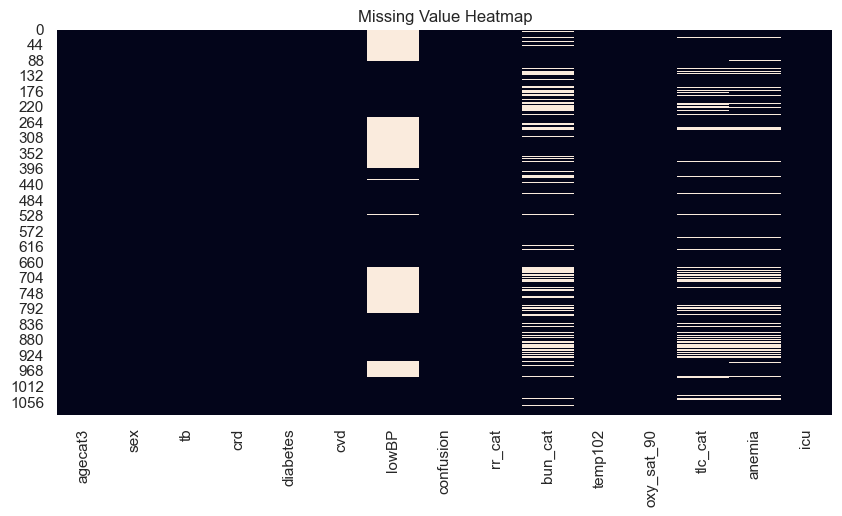

In [61]:
plt.figure(figsize=(10,5))
sns.heatmap(df_model.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

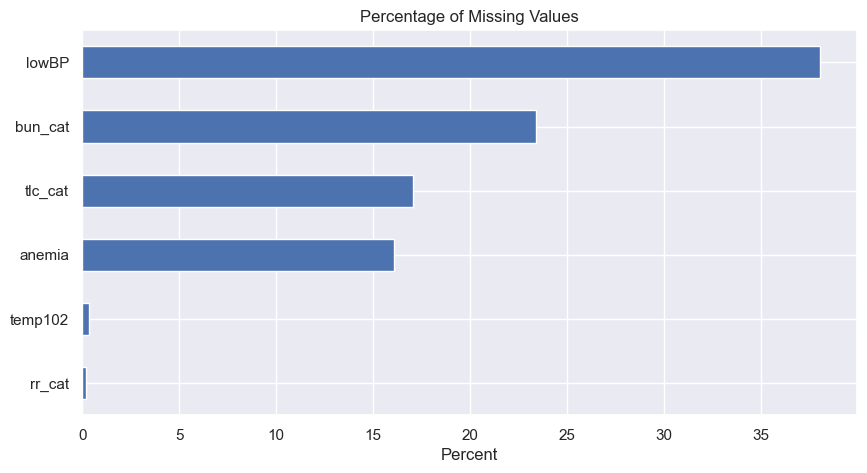

In [62]:
missing_percent = missing_percent[missing_percent > 0]
plt.figure(figsize=(10,5))
missing_percent.sort_values().plot(kind='barh')
plt.title("Percentage of Missing Values")
plt.xlabel("Percent")
plt.show()

# Data Preprocessing

Enconding Kolom Kategorikal

In [63]:
print(df_model.dtypes)
print ("Shape:", df_model.shape)

agecat3         int64
sex             int64
tb                str
crd               str
diabetes          str
cvd             int64
lowBP         float64
confusion       int64
rr_cat        float64
bun_cat       float64
temp102       float64
oxy_sat_90      int64
tlc_cat           str
anemia        float64
icu             int64
dtype: object
Shape: (1090, 15)


In [64]:
df_encoded = df_model.copy()
for col in df_encoded.select_dtypes(include=['string']).columns:
    df_encoded[col] = df_encoded[col].astype('object')

label_encoders = {}

for col in df_encoded.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    not_null = df_encoded[col].notnull()
    le.fit(df_encoded.loc[not_null, col])
    df_encoded.loc[not_null, col] = le.transform(df_encoded.loc[not_null, col])
    label_encoders[col] = le

In [65]:
for col, le in label_encoders.items():
    print(f"\nKolom: {col}")
    mapping = dict(zip(le.classes_, range(len(le.classes_))))
    print(mapping)


Kolom: tb
{'0': 0, 'Yes': 1}

Kolom: crd
{'0': 0, 'Yes': 1}

Kolom: diabetes
{'0': 0, 'Yes': 1}

Kolom: tlc_cat
{'5-20K': 0, '<5k': 1, '>20K': 2}


In [66]:
print(df_encoded.head())
print(df_encoded.dtypes)

   agecat3  sex tb crd diabetes  cvd  lowBP  confusion  rr_cat  bun_cat  \
0        2    2  1   1        0    0    NaN          1     0.0      0.0   
1        2    1  0   1        1    1    NaN          0     0.0      1.0   
2        3    1  0   0        1    1    NaN          0     0.0      1.0   
3        3    2  1   1        1    1    NaN          0     0.0      NaN   
4        2    1  0   1        1    1    NaN          0     0.0      NaN   

   temp102  oxy_sat_90 tlc_cat  anemia  icu  
0      0.0           0       0     0.0    0  
1      0.0           0       0     1.0    0  
2      0.0           0       0     1.0    0  
3      0.0           1     NaN     NaN    0  
4      0.0           0       2     1.0    0  
agecat3         int64
sex             int64
tb             object
crd            object
diabetes       object
cvd             int64
lowBP         float64
confusion       int64
rr_cat        float64
bun_cat       float64
temp102       float64
oxy_sat_90      int64
tlc_cat  

Penanganan Missing Value (BayesianRidge)

In [67]:
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    
    max_iter=20,
    random_state=42
)

df_imputed_array = imputer.fit_transform(df_encoded)

df_imputed = pd.DataFrame(
    df_imputed_array,
    columns=df_encoded.columns
)

Hasil Imputasi Missing Value

In [68]:
df_imputed.info()
df_imputed.head()

<class 'pandas.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   agecat3     1090 non-null   float64
 1   sex         1090 non-null   float64
 2   tb          1090 non-null   float64
 3   crd         1090 non-null   float64
 4   diabetes    1090 non-null   float64
 5   cvd         1090 non-null   float64
 6   lowBP       1090 non-null   float64
 7   confusion   1090 non-null   float64
 8   rr_cat      1090 non-null   float64
 9   bun_cat     1090 non-null   float64
 10  temp102     1090 non-null   float64
 11  oxy_sat_90  1090 non-null   float64
 12  tlc_cat     1090 non-null   float64
 13  anemia      1090 non-null   float64
 14  icu         1090 non-null   float64
dtypes: float64(15)
memory usage: 127.9 KB


,agecat3,sex,tb,crd,diabetes,cvd,lowBP,confusion,rr_cat,bun_cat,temp102,oxy_sat_90,tlc_cat,anemia,icu
0,2.0,2.0,1.0,1.0,0.0,0.0,0.016270,1.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0
1,2.0,1.0,0.0,1.0,1.0,1.0,0.009597,0.0,0.0,1.000000,0.0,0.0,0.000000,1.000000,0.0
2,3.0,1.0,0.0,0.0,1.0,1.0,0.009559,0.0,0.0,1.000000,0.0,0.0,0.000000,1.000000,0.0
3,3.0,2.0,1.0,1.0,1.0,1.0,0.026531,0.0,0.0,0.506632,0.0,1.0,0.361622,0.758499,0.0
4,2.0,1.0,0.0,1.0,1.0,1.0,0.023553,0.0,0.0,0.412867,0.0,0.0,2.000000,1.000000,0.0


In [69]:
for col in df_imputed.columns:
    print(col, ":", df_imputed[col].nunique())

agecat3 : 3
sex : 2
tb : 2
crd : 2
diabetes : 2
cvd : 2
lowBP : 361
confusion : 2
rr_cat : 4
bun_cat : 217
temp102 : 6
oxy_sat_90 : 3
tlc_cat : 157
anemia : 145
icu : 2


In [70]:
numeric_cols = df_imputed.select_dtypes(include=['float64']).columns
df_imputed[numeric_cols] = df_imputed[numeric_cols].round().astype(int)

In [71]:
x = df_imputed.drop("icu", axis=1)
y = df_imputed["icu"]

In [72]:
df_imputed.info()

<class 'pandas.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   agecat3     1090 non-null   int64
 1   sex         1090 non-null   int64
 2   tb          1090 non-null   int64
 3   crd         1090 non-null   int64
 4   diabetes    1090 non-null   int64
 5   cvd         1090 non-null   int64
 6   lowBP       1090 non-null   int64
 7   confusion   1090 non-null   int64
 8   rr_cat      1090 non-null   int64
 9   bun_cat     1090 non-null   int64
 10  temp102     1090 non-null   int64
 11  oxy_sat_90  1090 non-null   int64
 12  tlc_cat     1090 non-null   int64
 13  anemia      1090 non-null   int64
 14  icu         1090 non-null   int64
dtypes: int64(15)
memory usage: 127.9 KB


In [73]:
df_imputed.head(10)

,agecat3,sex,tb,crd,diabetes,cvd,lowBP,confusion,rr_cat,bun_cat,temp102,oxy_sat_90,tlc_cat,anemia,icu
0,2,2,1,1,0,0,0,1,0,0,0,0,0,0,0
1,2,1,0,1,1,1,0,0,0,1,0,0,0,1,0
2,3,1,0,0,1,1,0,0,0,1,0,0,0,1,0
3,3,2,1,1,1,1,0,0,0,1,0,1,0,1,0
4,2,1,0,1,1,1,0,0,0,0,0,0,2,1,0
5,3,2,0,1,1,1,0,0,0,1,0,0,0,1,1
6,2,1,0,1,1,1,0,0,0,0,0,0,0,0,0
7,2,2,0,1,0,1,0,0,0,0,0,0,0,0,0
8,2,2,0,1,0,1,0,0,0,1,0,0,0,1,0
9,3,2,0,0,1,1,0,0,0,0,0,0,0,1,1


Mengecek Keseimbangan Data

In [74]:
for col in df_imputed.columns:
    print(f"\nVariabel: {col}")
    print(df_imputed[col].value_counts())


Variabel: agecat3
agecat3
2    486
1    313
3    291
Name: count, dtype: int64

Variabel: sex
sex
2    671
1    419
Name: count, dtype: int64

Variabel: tb
tb
0    1024
1      66
Name: count, dtype: int64

Variabel: crd
crd
1    548
0    542
Name: count, dtype: int64

Variabel: diabetes
diabetes
0    785
1    305
Name: count, dtype: int64

Variabel: cvd
cvd
0    594
1    496
Name: count, dtype: int64

Variabel: lowBP
lowBP
0    1074
1      16
Name: count, dtype: int64

Variabel: confusion
confusion
0    1019
1      71
Name: count, dtype: int64

Variabel: rr_cat
rr_cat
0    986
1    104
Name: count, dtype: int64

Variabel: bun_cat
bun_cat
0    651
1    439
Name: count, dtype: int64

Variabel: temp102
temp102
0    1024
1      66
Name: count, dtype: int64

Variabel: oxy_sat_90
oxy_sat_90
0    694
2    245
1    151
Name: count, dtype: int64

Variabel: tlc_cat
tlc_cat
0    915
2    128
1     47
Name: count, dtype: int64

Variabel: anemia
anemia
1    815
0    275
Name: count, dtype: int64



Split Data

In [75]:
x=df_imputed.drop("icu", axis=1)
y=df_imputed["icu"]

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Klasifikasi Menggunakan XGBoost

Inisialisasi Grid

In [76]:
param_grid_xgg={
    'n_estimators':[50,100,150,200,250,300,350],
    'learning_rate':[0.01, 0.05, 0.065, 0,1],
    'max_depth':[5,10,15,20,25],
    'subsample':[0.8,0.9,1.0],
    'colsample_bytree':[0.7,0.8,0.9],
    'random_state':[42],
    'scale_pos_weight':[1,2,3]
}

In [77]:
param_grid_xg={
    'n_estimators':[100,200,300],
    'learning_rate':[0.01, 0.05, 0.065],
    'max_depth':[3,5,7],
    'subsample':[0.8,0.9,1.0],
    'colsample_bytree':[0.7,0.8,0.9],
    'random_state':[42],
    'scale_pos_weight':[1,2,3]
}

Inisialisasi Model

In [78]:
model=XGBClassifier(eval_metric='logloss',random_state=42)

Scoring Recall

In [79]:
#inisialisasi GridSearchCV
gridsearch_xg = GridSearchCV(estimator=model,
                             param_grid=param_grid_xg,
                             scoring='recall',
                             cv=5,
                             n_jobs=-1,
                             verbose=1)

gridsearch_xg.fit(x_train, y_train)
best_model1=gridsearch_xg.best_estimator_
print("Parameter terbaik:", gridsearch_xg.best_params_)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Parameter terbaik: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42, 'scale_pos_weight': 3, 'subsample': 1.0}


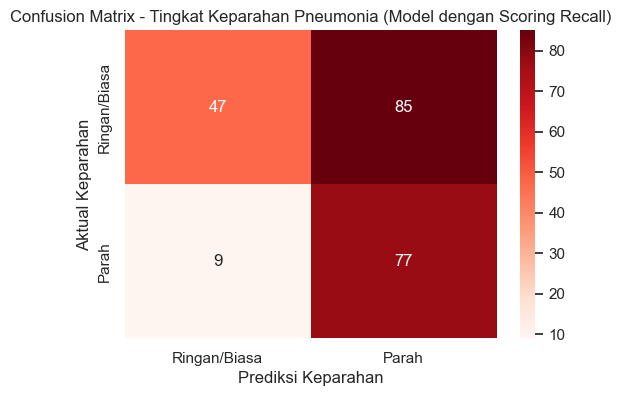


=== Laporan Klasifikasi Keparahan Pneumonia (Model dengan Scoring Recall) ===
              precision    recall  f1-score   support

Ringan/Biasa       0.84      0.36      0.50       132
       Parah       0.48      0.90      0.62        86

    accuracy                           0.57       218
   macro avg       0.66      0.63      0.56       218
weighted avg       0.70      0.57      0.55       218



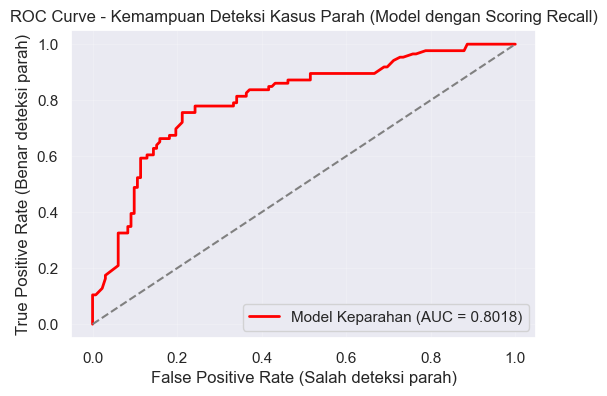

In [80]:
# 1. Hitung Prediksi
y_pred_proba = best_model1.predict_proba(x_test)[:, 1]

# 2. Confusion Matrix
threshold=0.5
y_pred1 = (y_pred_proba >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(6,4))
label_keparahan = ['Ringan/Biasa', 'Parah']

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=label_keparahan, 
            yticklabels=label_keparahan)

plt.xlabel('Prediksi Keparahan')
plt.ylabel('Aktual Keparahan')
plt.title('Confusion Matrix - Tingkat Keparahan Pneumonia (Model dengan Scoring Recall)')
plt.show()

# 3. Laporan Klasifikasi 
print("\n=== Laporan Klasifikasi Keparahan Pneumonia (Model dengan Scoring Recall) ===")
print(classification_report(y_test, y_pred1, target_names=label_keparahan))
# 4. Hitung Probabilitas untuk kelas 'Parah'
y_pred_proba = best_model1.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Model Keparahan (AUC = {auc_score:.4f})', color='red', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (Salah deteksi parah)')
plt.ylabel('True Positive Rate (Benar deteksi parah)')
plt.title('ROC Curve - Kemampuan Deteksi Kasus Parah (Model dengan Scoring Recall)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

Scoring F-1

In [81]:
#inisialisasi GridSearchCV
gridsearch_xg = GridSearchCV(estimator=model,
                             param_grid=param_grid_xg,
                             scoring='f1',
                             cv=5,
                             n_jobs=-1,
                             verbose=1)

gridsearch_xg.fit(x_train, y_train)
best_model2=gridsearch_xg.best_estimator_
print("Parameter terbaik:", gridsearch_xg.best_params_)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Parameter terbaik: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'random_state': 42, 'scale_pos_weight': 2, 'subsample': 0.9}


In [83]:
from xgboost import plot_tree
import matplotlib.pyplot as plt

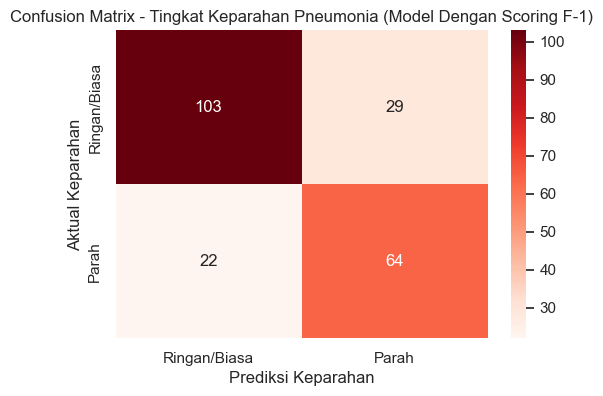


=== Laporan Klasifikasi Keparahan Pneumonia (Model Dengan Scoring F-1) ===
              precision    recall  f1-score   support

Ringan/Biasa       0.82      0.78      0.80       132
       Parah       0.69      0.74      0.72        86

    accuracy                           0.77       218
   macro avg       0.76      0.76      0.76       218
weighted avg       0.77      0.77      0.77       218



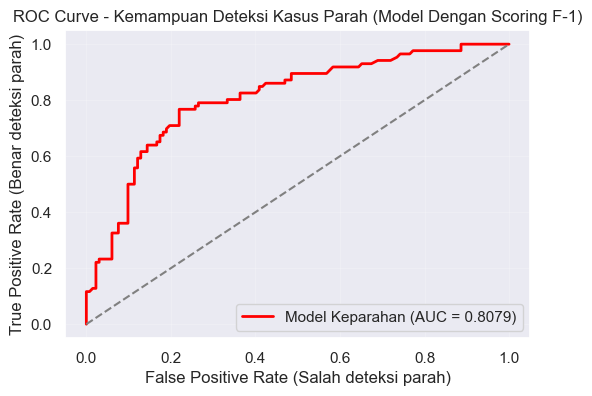

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0-0,oxy_sat_90,1.0,0-1,0-2,0-2,185.084381,263.574463,NaN
1,0,1,0-1,bun_cat,1.0,0-3,0-4,0-4,21.204590,146.785416,NaN
2,0,2,0-2,bun_cat,1.0,0-5,0-6,0-6,30.578766,116.789062,NaN
3,0,3,0-3,sex,2.0,0-7,0-8,0-8,5.917854,99.823914,NaN
4,0,4,0-4,crd,1.0,0-9,0-10,0-10,17.883923,46.961494,NaN
5,0,5,0-5,sex,2.0,0-11,0-12,0-12,6.015712,41.306446,NaN
6,0,6,0-6,oxy_sat_90,2.0,0-13,0-14,0-14,2.055092,75.482613,NaN
7,0,7,0-7,Leaf,NaN,NaN,NaN,NaN,-0.007159,43.519291,NaN
8,0,8,0-8,Leaf,NaN,NaN,NaN,NaN,-0.012427,56.304623,NaN
9,0,9,0-9,Leaf,NaN,NaN,NaN,NaN,-0.007837,24.341299,NaN


<Figure size 4000x2000 with 0 Axes>

In [ ]:
# 1. Hitung Prediksi
y_pred2 = best_model2.predict(x_test)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(6,4))
label_keparahan = ['Ringan/Biasa', 'Parah']

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=label_keparahan, 
            yticklabels=label_keparahan)

plt.xlabel('Prediksi Keparahan')
plt.ylabel('Aktual Keparahan')
plt.title('Confusion Matrix - Tingkat Keparahan Pneumonia (Model Dengan Scoring F-1)')
plt.show()

# 3. Laporan Klasifikasi 
print("\n=== Laporan Klasifikasi Keparahan Pneumonia (Model Dengan Scoring F-1) ===")
print(classification_report(y_test, y_pred2, target_names=label_keparahan))
# 4. Hitung Probabilitas untuk kelas 'Parah'
y_pred_proba = best_model2.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Model Keparahan (AUC = {auc_score:.4f})', color='red', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (Salah deteksi parah)')
plt.ylabel('True Positive Rate (Benar deteksi parah)')
plt.title('ROC Curve - Kemampuan Deteksi Kasus Parah (Model Dengan Scoring F-1)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()


Default XGBoost

In [ ]:
model_default=XGBClassifier()
model_default.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

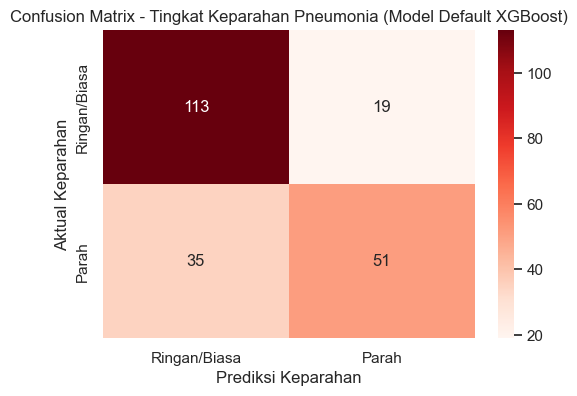


=== Laporan Klasifikasi Keparahan Pneumonia (Model Default XGBoost) ===
              precision    recall  f1-score   support

Ringan/Biasa       0.76      0.86      0.81       132
       Parah       0.73      0.59      0.65        86

    accuracy                           0.75       218
   macro avg       0.75      0.72      0.73       218
weighted avg       0.75      0.75      0.75       218



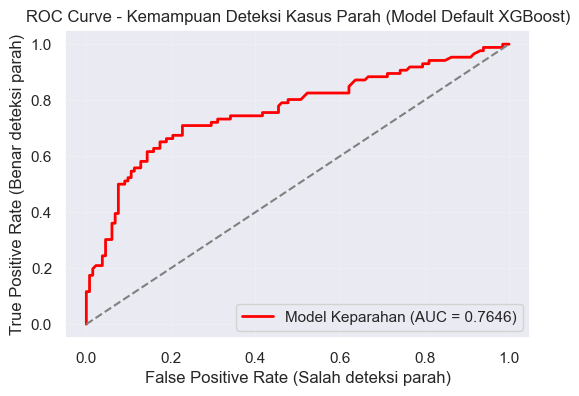

In [ ]:
# 1. Hitung Prediksi
y_preddef = model_default.predict(x_test)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_preddef)
plt.figure(figsize=(6,4))
label_keparahan = ['Ringan/Biasa', 'Parah']

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=label_keparahan, 
            yticklabels=label_keparahan)

plt.xlabel('Prediksi Keparahan')
plt.ylabel('Aktual Keparahan')
plt.title('Confusion Matrix - Tingkat Keparahan Pneumonia (Model Default XGBoost)')
plt.show()

# 3. Laporan Klasifikasi 
print("\n=== Laporan Klasifikasi Keparahan Pneumonia (Model Default XGBoost) ===")
print(classification_report(y_test, y_preddef, target_names=label_keparahan))
# 4. Hitung Probabilitas untuk kelas 'Parah'
y_pred_proba = model_default.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Model Keparahan (AUC = {auc_score:.4f})', color='red', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (Salah deteksi parah)')
plt.ylabel('True Positive Rate (Benar deteksi parah)')
plt.title('ROC Curve - Kemampuan Deteksi Kasus Parah (Model Default XGBoost)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

# Analisis Probabilitas Model

In [ ]:
y_pred_proba = best_model2.predict_proba(x_test)[:, 1]
brier_score_loss(y_test,y_pred_proba)

0.19694039225578308

# Kalibrasi Probabilitas Model

Scoring F1

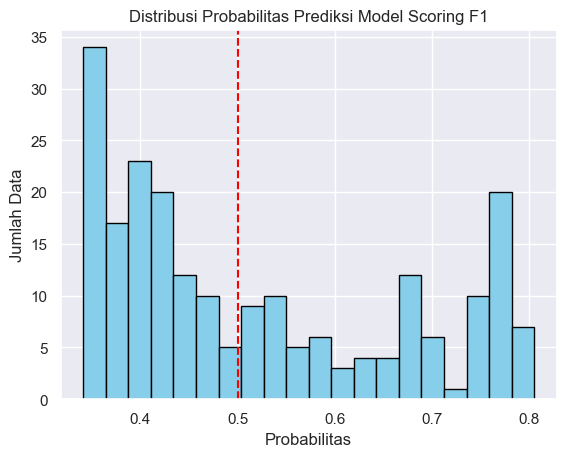

In [ ]:
probs=best_model2.predict_proba(x_test)[:,1]
plt.hist(probs,bins=20,color='skyblue',edgecolor='black')
plt.axvline(0.5,color='red',linestyle='--')
plt.title("Distribusi Probabilitas Prediksi Model Scoring F1")
plt.xlabel("Probabilitas")
plt.ylabel("Jumlah Data")
plt.show()

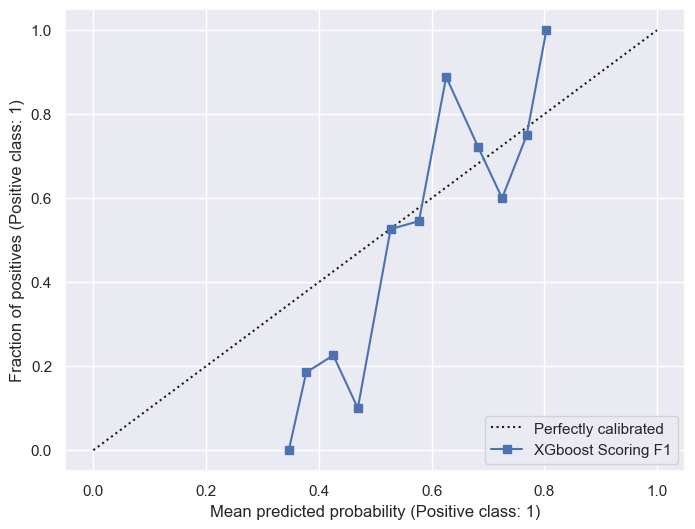

In [ ]:
fig, ax=plt.subplots(figsize=(8,6))
CalibrationDisplay.from_estimator(best_model2,x_test,y_test,n_bins=20,name='XGboost Scoring F1',ax=ax)


In [ ]:
calibrated2=CalibratedClassifierCV(
    estimator=best_model2,
    method='sigmoid',
    cv=5
)
calibrated2.fit(x_train,y_train)
print("Kalibrasi Selesai!")
#probabilitas 
new_probs=calibrated2.predict_proba(x_test)[:,1]
old_probs=best_model2.predict_proba(x_test)[:,1]
# Hitung skor
score_lama = brier_score_loss(y_test, old_probs)
score_baru = brier_score_loss(y_test, new_probs)

print(f"Brier Score Model F1: {score_lama:.4f}")
print(f"Brier Score Model F1 Terkalibrasi: {score_baru:.4f}")

Kalibrasi Selesai!
Brier Score Model F1: 0.1969
Brier Score Model F1 Terkalibrasi: 0.1682


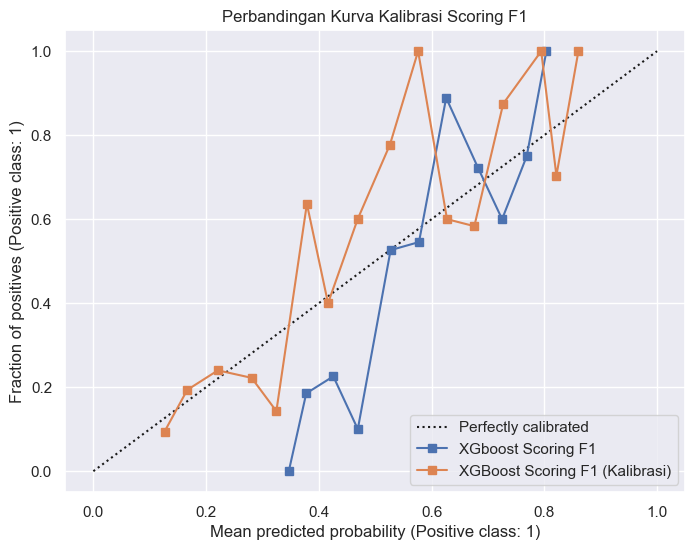

In [ ]:
fig, ax=plt.subplots(figsize=(8,6))
CalibrationDisplay.from_estimator(best_model2,x_test,y_test,n_bins=20,name='XGboost Scoring F1',ax=ax)
CalibrationDisplay.from_estimator(calibrated2,x_test,y_test,n_bins=20, name="XGBoost Scoring F1 (Kalibrasi)", ax=ax)
plt.title("Perbandingan Kurva Kalibrasi Scoring F1")
plt.show()

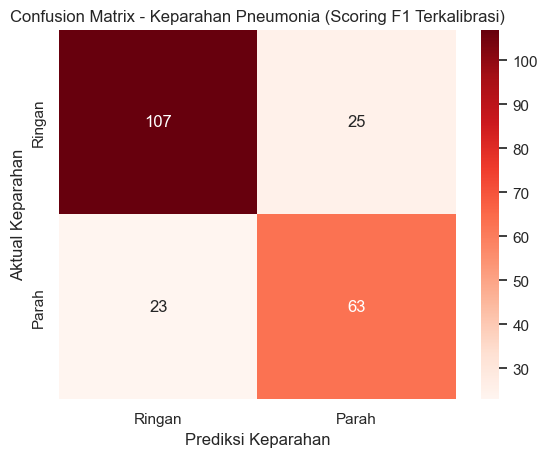


=== Laporan Klasifikasi Keparahan Pneumonia (Scoring F1 Terkalibrasi) ===
              precision    recall  f1-score   support

      Ringan       0.78      0.86      0.82       132
       Parah       0.75      0.63      0.68        86

    accuracy                           0.77       218
   macro avg       0.77      0.75      0.75       218
weighted avg       0.77      0.77      0.77       218



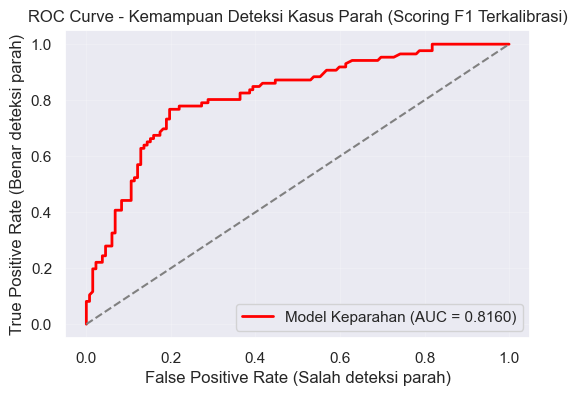

In [ ]:
#1. Hitung Prediksi
y_predcal2=calibrated2.predict(x_test)
#2. Confucion Matrix
threshold_baru = 0.38
y_pred_custom = (new_probs >= threshold_baru).astype(int)
cm=confusion_matrix(y_test,y_pred_custom)
plt.Figure(figsize=(6,4))
label_keparahan=['Ringan','Parah']
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',
            xticklabels=label_keparahan,
            yticklabels=label_keparahan)

plt.xlabel('Prediksi Keparahan')
plt.ylabel('Aktual Keparahan')
plt.title('Confusion Matrix - Keparahan Pneumonia (Scoring F1 Terkalibrasi)')
plt.show()
#3. Laporan Klasifikasi
print("\n=== Laporan Klasifikasi Keparahan Pneumonia (Scoring F1 Terkalibrasi) ===")
print(classification_report(y_test, y_predcal2, target_names=label_keparahan))
#4. Hitung Probabilitas
y_pred_proba=calibrated2.predict_proba(x_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Model Keparahan (AUC = {auc_score:.4f})', color='red', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (Salah deteksi parah)')
plt.ylabel('True Positive Rate (Benar deteksi parah)')
plt.title('ROC Curve - Kemampuan Deteksi Kasus Parah (Scoring F1 Terkalibrasi)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
new_probs=calibrated2.predict_proba(x_test)[:,1]
old_probs=best_model2.predict_proba(x_test)[:,1]
old_loss = log_loss(y_test,old_probs)
new_loss = log_loss(y_test, new_probs)
print(f"Log Loss Model Scoring F1:{old_loss:.4f}")
print(f"Log Loss Model Scoring F1 Terkalibrasi: {new_loss:.4f}")


Log Loss Model Scoring F1:0.5834
Log Loss Model Scoring F1 Terkalibrasi: 0.5134


# Analisis SHAP


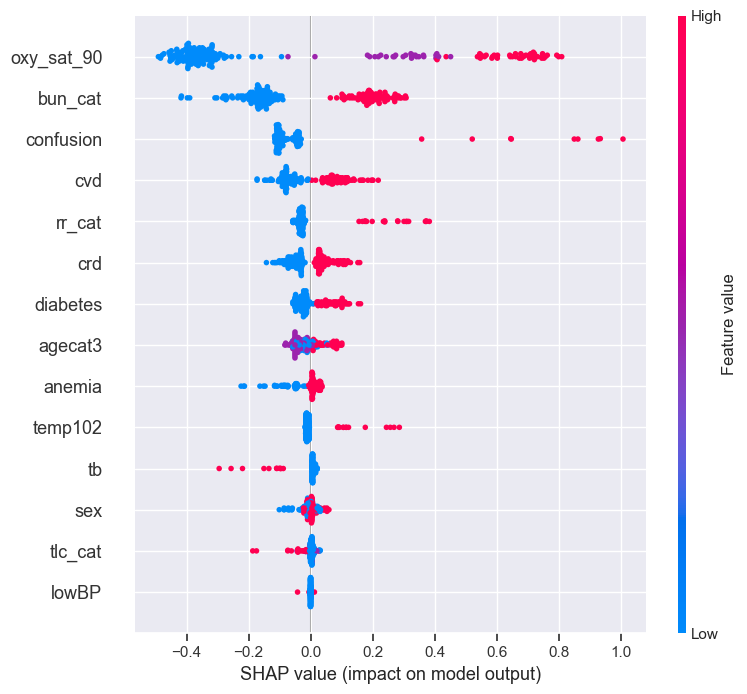

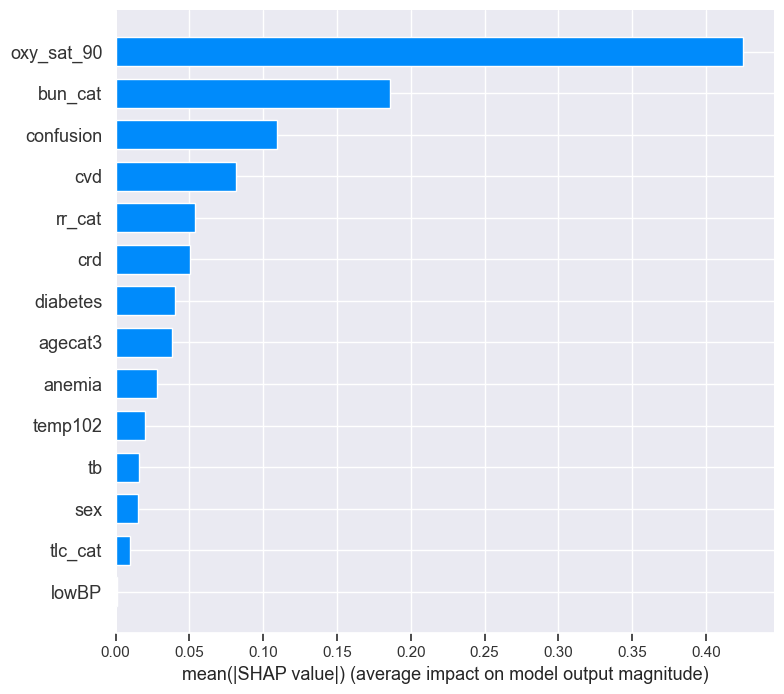

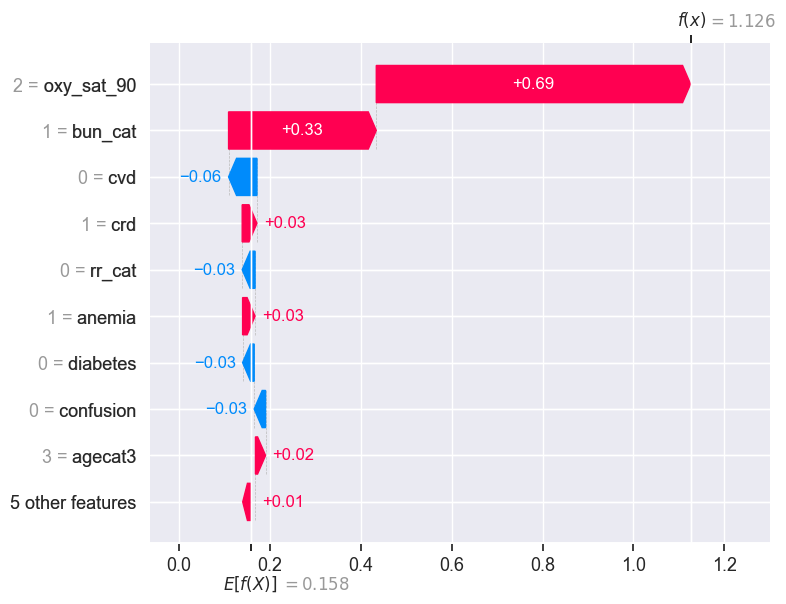

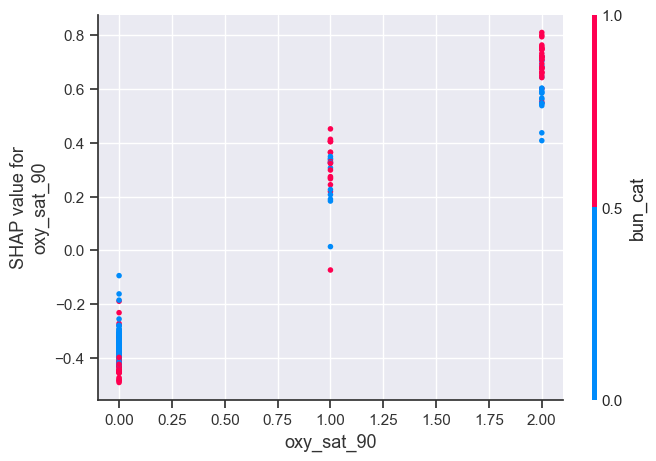

In [ ]:
model_shap = best_model2
explainer=shap.TreeExplainer(model_shap)
shap_values=explainer.shap_values(x_test)
x_test_df=pd.DataFrame(x_test,columns=x.columns)
shap.summary_plot(shap_values, x_test_df)
shap.summary_plot(shap_values, x_test_df, plot_type='bar')
explainer_new = shap.Explainer(model_shap, x_test_df)
shap_values_new = explainer_new(x_test_df)
shap.plots.waterfall(shap_values_new[0])
shap.dependence_plot('oxy_sat_90', shap_values, x_test_df)

# Buat File .PKL

In [ ]:
joblib.dump(calibrated2, 'model_xgboost2.pkl')

['model_xgboost2.pkl']

In [ ]:
joblib.dump(label_encoders, 'label_encoders.pkl')

['label_encoders.pkl']